# EDA de Sentinel-2 sobre Cali

Sentinel-2 es un par de satélites europeos que fotografían la superficie de la Tierra en varios colores, varios de ellos invisibles para el ojo. No miran gases ni mide calidad del aire de forma directa: lo que entregan es reflectancia, o sea qué fracción de la luz del sol rebota en cada pedazo de suelo. De ahí salen cosas como cuánta vegetación hay, dónde está lo construido o qué tan húmedo está el terreno, que son justamente las pistas finas que el resto del proyecto necesita para bajar la resolución de los gases de Sentinel-5P.

Para Cali trabajamos con siete capas por escena: cuatro bandas a 10 metros (azul **B02**, verde **B03**, rojo **B04** e infrarrojo cercano **B08**), una banda de infrarrojo de onda corta a 20 metros (**B11**), la clasificación de escena (**SCL**, que dice qué hay en cada píxel) y la probabilidad de nube (**MSK_CLDPRB**). Con esas bandas alcanza para los índices del proyecto y para el recorte que alimenta al modelo.

Hay una idea que conviene tener clara desde el arranque: el número que trae cada píxel no es la reflectancia todavía. Sentinel-2 guarda enteros con un corrimiento, así que para obtener el valor físico hay que restarle 1.000 y dividir entre 10.000. Esa cuenta aparece temprano y se arrastra hasta el final, porque si se salta, todo queda inflado.

## Preparación

Dejamos el entorno listo antes de tocar las imágenes: herramientas, estilo, dónde están los datos y unas constantes del dominio.

### *Importación de dependencias*

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from pyproj import Transformer

### *Estilo de las gráficas y semilla*

In [2]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 137
rng = np.random.default_rng(SEED)

### *Ubicación de los datos*

In [3]:
BRONZE = Path(os.environ.get("S2_BRONZE", r"D:\analitica\bronze\sentinel-2-l2a"))
if not BRONZE.exists():
    raise FileNotFoundError(f"No encuentro el bronce de Sentinel-2 en {BRONZE}")
print("Bronce Sentinel-2:", BRONZE)

Bronce Sentinel-2: D:\analitica\bronze\sentinel-2-l2a


### *Constantes del dominio*

In [4]:
# Los cuatro tiles MGRS que cubren el suroccidente del Valle. Solo uno cae sobre Cali.
TILES = ["T18NTH", "T18NTJ", "T18NUH", "T18NUJ"]
TILE_URBANO = "T18NUJ"

# Huella metropolitana de Cali en longitud y latitud (EPSG:4326).
BBOX_4326 = (-76.60, 3.30, -76.40, 3.55)  # lonmin, latmin, lonmax, latmax

# Conversión del entero crudo a reflectancia de superficie: refl = (DN + offset) / quant.
OFFSET, QUANT = -1000.0, 10000.0

# Clases de SCL que dejamos pasar y umbral de probabilidad de nube.
SCL_VALIDAS = [4, 5, 6, 7, 11]
CLDPRB_MAX = 35
SCL_NOMBRE = {0: "sin dato", 1: "saturado", 2: "área oscura", 3: "sombra de nube",
              4: "vegetación", 5: "suelo", 6: "agua", 7: "sin clasificar",
              8: "nube media", 9: "nube alta", 10: "cirrus", 11: "nieve"}

# Color por banda para las figuras.
COL = {"B02": "#1f77b4", "B03": "#2ca02c", "B04": "#d62728", "B08": "#7f3fbf", "B11": "#8c564b"}

# Las nueve estaciones de DAGMA (lon, lat), para situarlas sobre el tile urbano.
ESTACIONES = {
    "Base Aérea": (-76.50653649, 3.45731978),
    "ERA Obrero": (-76.51908184, 3.44759410),
    "Cañaveralejo": (-76.54961789, 3.41545841),
    "Univalle": (-76.53372474, 3.37796681),
    "Pance": (-76.53125401, 3.30449556),
    "Transitoria": (-76.49495633, 3.41717874),
    "Compartir": (-76.46657547, 3.42825808),
    "La Flora": (-76.51805771, 3.48822548),
    "La Ermita": (-76.53097834, 3.45551754),
}

# El BBox reproyectado a UTM 18N (EPSG:32618), que es el sistema nativo de las escenas.
_tr = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
XMIN, YMIN = _tr.transform(BBOX_4326[0], BBOX_4326[1])
XMAX, YMAX = _tr.transform(BBOX_4326[2], BBOX_4326[3])

### *Funciones de apoyo*

In [5]:
def fmt(n, dec=0):
    """Número al estilo local: punto para miles, coma para decimales."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def parse_safe(nombre):
    """Saca satélite, fecha, baseline, órbita y tile del nombre del producto."""
    p = nombre.replace(".SAFE", "").split("_")
    return {"sat": p[0], "fecha": pd.to_datetime(p[2][:8]), "baseline": p[3],
            "orbita": p[4], "tile": p[5]}


def escenas(tile):
    """Lista ordenada de carpetas .SAFE de un tile, ya parseadas."""
    filas = []
    for safe in sorted((BRONZE / tile).glob("*.SAFE")):
        d = parse_safe(safe.name)
        d["path"] = safe
        filas.append(d)
    return filas


def jp2(safe, banda):
    """Ruta del JP2 de una banda dentro de una escena (maneja 10m, 20m y QI_DATA)."""
    g = next((safe / "GRANULE").iterdir())
    if banda == "MSK_CLDPRB":
        return next((g / "QI_DATA").glob("MSK_CLDPRB_20m.jp2"))
    sub = "R10m" if banda in ("B02", "B03", "B04", "B08") else "R20m"
    return next((g / "IMG_DATA" / sub).glob(f"*_{banda}_{sub[1:]}.jp2"))


def leer(safe, banda, shape=None):
    """Lee una banda recortada al BBox de Cali. Si se pide shape, remuestrea a ese tamaño."""
    with rasterio.open(jp2(safe, banda)) as src:
        win = from_bounds(XMIN, YMIN, XMAX, YMAX, src.transform)
        kw = dict(window=win, boundless=True, fill_value=0)
        if shape is not None:
            kw.update(out_shape=shape, resampling=Resampling.bilinear)
        return src.read(1, **kw).astype("float64")


def reflectancia(dn):
    """Pasa el entero crudo a reflectancia de superficie y deja el sin dato como NaN."""
    r = (dn + OFFSET) / QUANT
    return np.where(dn > 0, r, np.nan)


def mascara_validez(scl, cld):
    """Píxeles utilizables: clase de SCL aceptada y baja probabilidad de nube."""
    return np.isin(scl, SCL_VALIDAS) & (cld < CLDPRB_MAX)


def indice(a, b):
    """Diferencia normalizada (a - b) / (a + b) con guarda para el denominador chico."""
    den = a + b
    with np.errstate(divide="ignore", invalid="ignore"):
        v = np.where(np.abs(den) > 0.01, (a - b) / den, np.nan)
    return v


def estirar(arr):
    """Lleva una banda a [0, 1] estirando entre los percentiles 2 y 98, solo para verla."""
    finito = arr[np.isfinite(arr)]
    lo, hi = np.nanpercentile(finito, [2, 98])
    return np.clip((arr - lo) / (hi - lo), 0, 1)

## 1. Qué tenemos en la mano

Cada escena es una carpeta con forma de nombre larga que ya trae casi toda la ficha técnica: el satélite que la tomó, la fecha, la versión del procesador y el tile. Sin abrir ninguna imagen, recorremos las cuatro carpetas de tile y armamos la lista completa partiendo ese nombre por sus guiones.

Escenas en total:  472
Período cubierto:  2020-01-02 a 2024-12-16
Satélites:         S2B 255, S2A 215, S2C 2
Baselines:         N0500 154, N0510 257, N0511 60, N9905 1


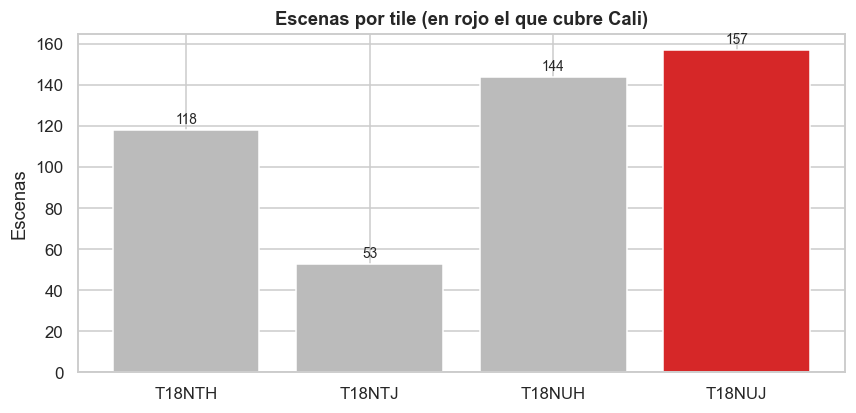

In [6]:
inv = pd.DataFrame([d for t in TILES for d in escenas(t)])
inv["anio"] = inv["fecha"].dt.year

print(f"Escenas en total:  {fmt(len(inv))}")
print(f"Período cubierto:  {inv['fecha'].min().date()} a {inv['fecha'].max().date()}")
print(f"Satélites:         " + ", ".join(f"{k} {fmt(v)}" for k, v in inv['sat'].value_counts().items()))
print(f"Baselines:         " + ", ".join(f"{k} {fmt(v)}" for k, v in inv['baseline'].value_counts().sort_index().items()))

fig, ax = plt.subplots(figsize=(9, 4))
conteo = inv["tile"].value_counts().reindex(TILES)
barras = ax.bar(TILES, conteo.values, color=["#bbbbbb", "#bbbbbb", "#bbbbbb", "#d62728"], edgecolor="white")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 3, fmt(v), ha="center", fontsize=9)
ax.set_ylabel("Escenas")
ax.set_title("Escenas por tile (en rojo el que cubre Cali)")
plt.show()

Tenemos 472 escenas de los cinco años, repartidas de forma muy despareja entre los cuatro tiles. T18NUJ se lleva 157 y T18NTJ apenas 53. Casi todas traen baseline 05.00, 05.10 o 05.11; una sola, la más reciente y del satélite nuevo S2C, viene de un reprocesamiento aparte. Todas caen en la generación de catálogo que usa el mismo corrimiento para la reflectancia, un detalle que retomamos en la sección 4. Por ahora basta quedarse con que el grueso del material útil va a salir de un solo tile.

## 2. Cuatro recortes del mapa, uno solo sobre Cali

Los cuatro tiles son cuadrados de 110 kilómetros de lado en coordenadas UTM. Para saber cuál nos sirve, leemos las esquinas reales de una escena de cada uno (no las dibujamos a ojo) y medimos qué tanto del recuadro de Cali queda dentro de cada cuadrado. Encima ubicamos las nueve estaciones de DAGMA, que son la referencia de suelo del proyecto.

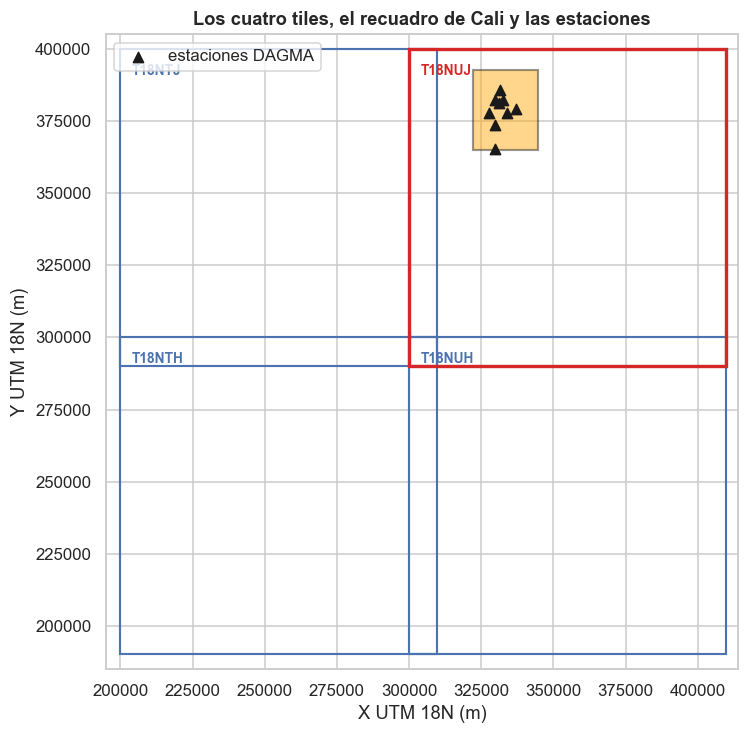

T18NTH: cubre 0,0% del recuadro de Cali
T18NTJ: cubre 0,0% del recuadro de Cali
T18NUH: cubre 0,0% del recuadro de Cali
T18NUJ: cubre 100,0% del recuadro de Cali


In [7]:
bounds = {}
for t in TILES:
    with rasterio.open(jp2(inv[inv.tile == t].iloc[0]["path"], "B02")) as src:
        bounds[t] = src.bounds
aoi = (XMAX - XMIN) * (YMAX - YMIN)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
for t in TILES:
    b = bounds[t]
    es_urbano = t == TILE_URBANO
    ax.add_patch(Rectangle((b.left, b.bottom), b.right - b.left, b.top - b.bottom,
                           fill=False, edgecolor="#d62728" if es_urbano else "#4c72b0",
                           lw=2.2 if es_urbano else 1.4))
    ax.text(b.left + 4000, b.top - 9000, t, color="#d62728" if es_urbano else "#4c72b0",
            fontsize=9, weight="bold")
ax.add_patch(Rectangle((XMIN, YMIN), XMAX - XMIN, YMAX - YMIN,
                       facecolor="orange", alpha=0.45, edgecolor="k", lw=1.4))
ex = [_tr.transform(lon, lat) for lon, lat in ESTACIONES.values()]
ax.scatter([e[0] for e in ex], [e[1] for e in ex], marker="^", c="k", s=45, zorder=5, label="estaciones DAGMA")
ax.set_xlim(195000, 414000); ax.set_ylim(185000, 405000); ax.set_aspect("equal")
ax.set_xlabel("X UTM 18N (m)"); ax.set_ylabel("Y UTM 18N (m)")
ax.set_title("Los cuatro tiles, el recuadro de Cali y las estaciones")
ax.legend(loc="upper left")
plt.show()

for t in TILES:
    b = bounds[t]
    ix = max(0.0, min(b.right, XMAX) - max(b.left, XMIN))
    iy = max(0.0, min(b.top, YMAX) - max(b.bottom, YMIN))
    print(f"{t}: cubre {fmt(100 * ix * iy / aoi, 1)}% del recuadro de Cali")

El resultado es tajante: T18NUJ cubre el 100% del recuadro de Cali y los otros tres lo tocan en un 0%. Las nueve estaciones de DAGMA caen todas dentro de ese mismo tile. Los otros tres tiles quedan al sur (Jamundí), al occidente (vertiente del Pacífico) y al suroccidente rural, así que aportan contexto regional pero no entran al análisis urbano. De aquí en adelante, cuando miremos píxeles sobre la ciudad, lo hacemos sobre T18NUJ.

## 3. Cuándo nos visita el satélite

Sentinel-2 pasa sobre el mismo punto cada cinco días contando los dos satélites, pero eso es la promesa de la órbita, no lo que llega utilizable. Cali está cerca del ecuador, en plena zona de nubes, así que muchas pasadas quedan tapadas. Un mapa de calor de cuántas escenas hay por mes y año en T18NUJ deja ver de una vez si el reparto es parejo o si hay temporadas flacas.

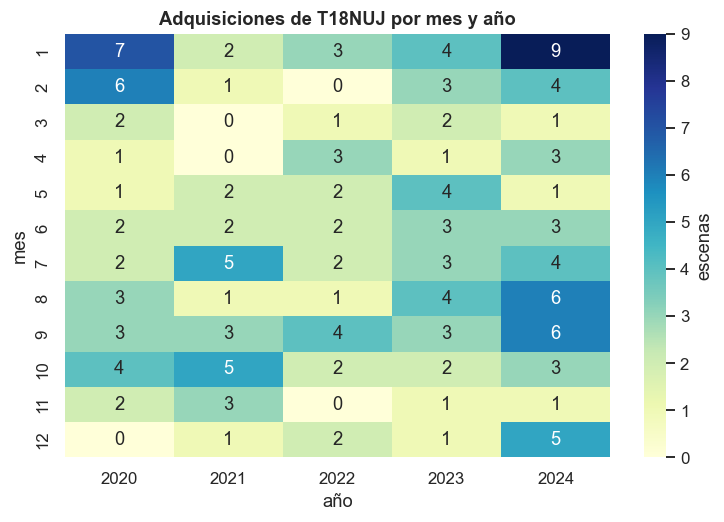

Tramos de más de 30 días sin ninguna escena: 7
Hueco más largo entre escenas seguidas:      70 días


In [8]:
u = inv[inv.tile == TILE_URBANO].copy()
u["mes"] = u["fecha"].dt.month
piv = u.pivot_table(index="mes", columns="anio", values="path", aggfunc="count").reindex(range(1, 13)).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "escenas"})
ax.set_title("Adquisiciones de T18NUJ por mes y año")
ax.set_xlabel("año"); ax.set_ylabel("mes")
plt.show()

fechas = u["fecha"].sort_values()
print(f"Tramos de más de 30 días sin ninguna escena: {fmt((fechas.diff().dt.days > 30).sum())}")
print(f"Hueco más largo entre escenas seguidas:      {fmt(fechas.diff().dt.days.max())} días")

El reparto es irregular. Hay meses con una sola escena y otros con siete u ocho, y aparecen tramos de más de un mes sin nada aprovechable. La revisita de cinco días no se cumple en la práctica porque la nube se come buena parte de las pasadas. Esto marca el ritmo de cualquier covariable óptica que se quiera armar: no hay un dato cómodo cada cinco días, sino lo que las nubes dejen pasar.

## 4. Del número crudo a la reflectancia

El valor que trae cada píxel es un entero, no la reflectancia. Desde la versión de procesador con la que vienen estas escenas, el satélite guarda los datos con un corrimiento para no recortar los valores oscuros, y hay que deshacerlo. La cuenta es:

$$\rho = \frac{DN + \text{offset}}{\text{cuantificación}} = \frac{DN - 1000}{10000}$$

donde $DN$ es el entero guardado en el píxel, el offset vale -1.000 y la cuantificación 10.000. En palabras: a cada píxel se le resta 1.000 y se divide entre 10.000. El 0 está reservado para "sin dato", así que queda por fuera de la cuenta. Pueden salir reflectancias un poquito negativas sobre agua oscura o sombra, y son válidas, no son huecos.

Banda azul B02, media en bruto: DN = 3.200
Reflectancia sin corregir: media = 0,320
Reflectancia corregida:    media = 0,220


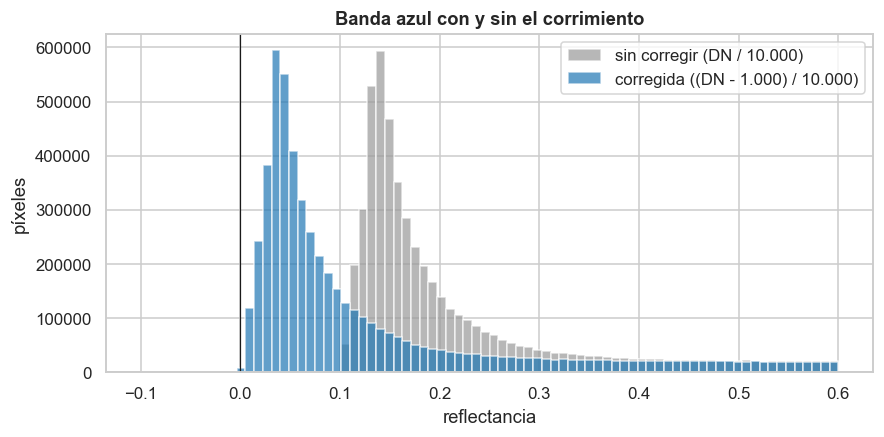

In [9]:
esc = inv[inv.tile == TILE_URBANO].iloc[0]["path"]
v = leer(esc, "B02")
v = v[v > 0]
r_sin, r_con = v / QUANT, (v + OFFSET) / QUANT
print(f"Banda azul B02, media en bruto: DN = {fmt(v.mean())}")
print(f"Reflectancia sin corregir: media = {fmt(r_sin.mean(), 3)}")
print(f"Reflectancia corregida:    media = {fmt(r_con.mean(), 3)}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(r_sin, bins=80, range=(-0.1, 0.6), color="#999999", alpha=0.7, label="sin corregir (DN / 10.000)")
ax.hist(r_con, bins=80, range=(-0.1, 0.6), color=COL["B02"], alpha=0.7, label="corregida ((DN - 1.000) / 10.000)")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("reflectancia"); ax.set_ylabel("píxeles")
ax.set_title("Banda azul con y sin el corrimiento")
ax.legend()
plt.show()

Las dos curvas son la misma forma corrida 0,1 en reflectancia. Saltarse la corrección deja todo inflado en esa cantidad. El problema no es solo cosmético: los índices que vienen después son cocientes con una suma en el denominador, y ahí el corrimiento no se cancela como sí lo haría en una resta sola. Por eso la reflectancia corregida es la base de todo lo que sigue.

## 5. Cuánto tapan las nubes

Cada escena trae dos capas de control de calidad: SCL, que clasifica cada píxel (vegetación, suelo, agua, nube, sombra y demás), y MSK_CLDPRB, la probabilidad de que el píxel sea nube. Damos por bueno un píxel cuando su clase de SCL es de las aprovechables (vegetación, suelo, agua, sin clasificar o nieve) y además su probabilidad de nube es menor a 35. Con eso medimos, escena por escena, qué porcentaje del recuadro de Cali queda utilizable.

In [10]:
filas = []
for e in escenas(TILE_URBANO):
    scl = leer(e["path"], "SCL")
    cld = leer(e["path"], "MSK_CLDPRB", shape=scl.shape)
    ok = mascara_validez(scl, cld)
    filas.append({"fecha": e["fecha"], "sat": e["sat"], "path": e["path"],
                  "pct_validos": 100 * ok.mean()})
validez = pd.DataFrame(filas).sort_values("fecha").reset_index(drop=True)
validez["anio"] = validez["fecha"].dt.year

print(f"Escenas de T18NUJ:    {fmt(len(validez))}")
print(f"Píxeles válidos:      mediana {fmt(validez.pct_validos.median(), 1)}%, media {fmt(validez.pct_validos.mean(), 1)}%")
utiles = int((validez.pct_validos >= 50).sum())
print(f"Escenas medio limpias: {fmt(utiles)} con al menos 50% útil ({fmt(100 * utiles / len(validez), 0)}%)")
por_anio = validez.groupby("anio")["pct_validos"].apply(lambda s: int((s >= 50).sum()))
print("Útiles por año:       " + ", ".join(f"{a}: {fmt(n)}" for a, n in por_anio.items()))

Escenas de T18NUJ:    157
Píxeles válidos:      mediana 51,0%, media 46,4%
Escenas medio limpias: 79 con al menos 50% útil (50%)
Útiles por año:       2020: 17, 2021: 15, 2022: 8, 2023: 13, 2024: 26


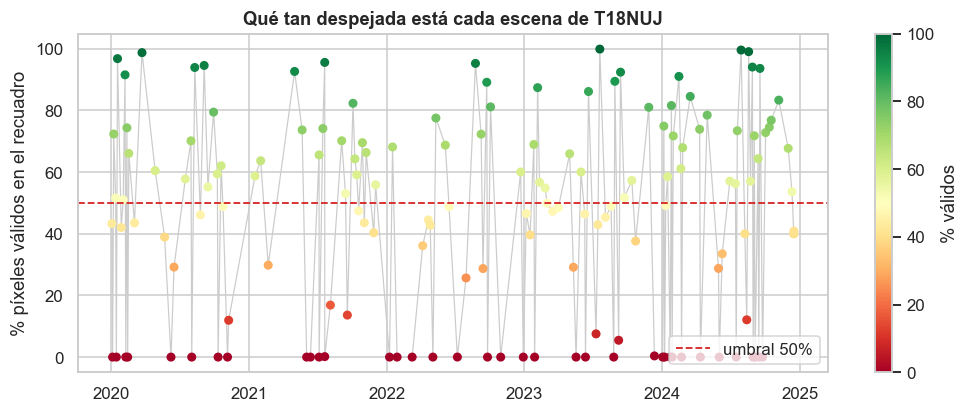

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(validez.fecha, validez.pct_validos, "-", color="#cccccc", lw=0.8, zorder=1)
sc = ax.scatter(validez.fecha, validez.pct_validos, c=validez.pct_validos,
                cmap="RdYlGn", vmin=0, vmax=100, s=24, zorder=2)
ax.axhline(50, color="#d62728", ls="--", lw=1.2, label="umbral 50%")
ax.set_ylabel("% píxeles válidos en el recuadro")
ax.set_title("Qué tan despejada está cada escena de T18NUJ")
ax.legend(loc="lower right")
plt.colorbar(sc, ax=ax, label="% válidos")
plt.show()

La mediana ronda el 51%, o sea que la mitad de las escenas tiene menos de la mitad del recuadro utilizable. Con el umbral del 50% que pide el proyecto, quedan cerca de 79 escenas aprovechables de las 157. El peor año fue 2022 y el mejor 2024. La nubosidad no es un detalle: recorta a la mitad el material óptico, y eso condiciona en qué fechas se puede apoyar el downscaling con una covariable de superficie confiable.

## 6. Cómo se ve cada banda

Ahora que sabemos convertir el entero en reflectancia y separar lo despejado, miramos qué valores toma cada banda sobre la ciudad. Recorremos las escenas medio limpias, les aplicamos la máscara de validez y resumimos cada banda con su mediana, que aguanta bien los píxeles raros que se cuelan pese al filtro.

In [12]:
filas = []
for r in validez[validez.pct_validos >= 50].itertuples():
    scl = leer(r.path, "SCL")
    H, W = scl.shape
    cld = leer(r.path, "MSK_CLDPRB", shape=(H, W))
    R = {b: reflectancia(leer(r.path, b, shape=(H, W))) for b in ("B02", "B03", "B04", "B08", "B11")}
    m = mascara_validez(scl, cld)
    d = {"fecha": r.fecha}
    for b, arr in R.items():
        d[b] = float(np.nanmedian(arr[m]))
    d["NDVI"] = float(np.nanmedian(indice(R["B08"], R["B04"])[m]))
    d["NDBI"] = float(np.nanmedian(indice(R["B11"], R["B08"])[m]))
    d["NDMI"] = float(np.nanmedian(indice(R["B08"], R["B11"])[m]))
    d["BSI"] = float(np.nanmedian(indice(R["B11"] + R["B04"], R["B08"] + R["B02"])[m]))
    filas.append(d)
optico = pd.DataFrame(filas).sort_values("fecha").reset_index(drop=True)

print("Reflectancia mediana por banda (sobre las escenas medio limpias):")
for b in ("B02", "B03", "B04", "B08", "B11"):
    print(f"  {b}: {fmt(optico[b].median(), 3)}")

Reflectancia mediana por banda (sobre las escenas medio limpias):
  B02: 0,059
  B03: 0,080
  B04: 0,070
  B08: 0,272
  B11: 0,210


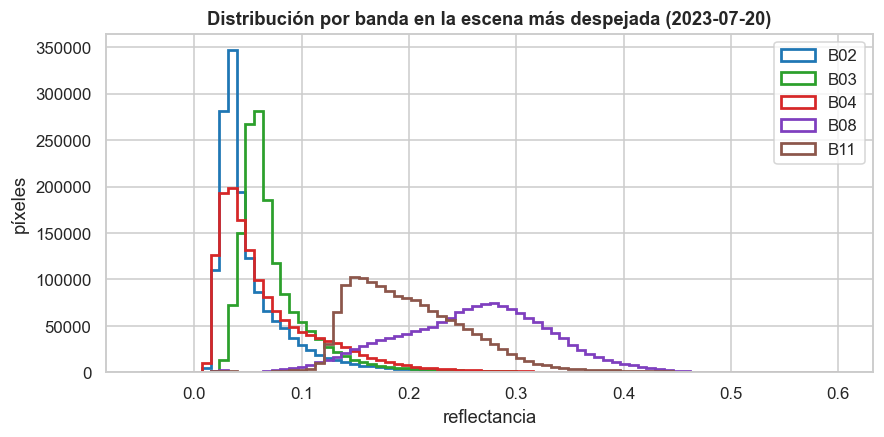

In [13]:
mejor = validez.sort_values("pct_validos").iloc[-1]
scl = leer(mejor.path, "SCL")
H, W = scl.shape
cld = leer(mejor.path, "MSK_CLDPRB", shape=(H, W))
m = mascara_validez(scl, cld)

fig, ax = plt.subplots(figsize=(9, 4))
for b in ("B02", "B03", "B04", "B08", "B11"):
    arr = reflectancia(leer(mejor.path, b, shape=(H, W)))[m]
    ax.hist(arr[np.isfinite(arr)], bins=80, range=(-0.05, 0.6), histtype="step",
            lw=1.8, color=COL[b], label=b)
ax.set_xlabel("reflectancia"); ax.set_ylabel("píxeles")
ax.set_title(f"Distribución por banda en la escena más despejada ({mejor.fecha.date()})")
ax.legend()
plt.show()

El patrón es el de una superficie con mucha vegetación: el azul, el verde y el rojo se quedan abajo, entre 0,05 y 0,10, mientras que el infrarrojo cercano se dispara hasta cerca de 0,27 y el infrarrojo de onda corta queda en medio, cerca de 0,21. Ese salto del rojo al infrarrojo cercano es justo lo que hace que el NDVI funcione. Las magnitudes son las esperadas para reflectancia de superficie bien corregida, sin valores pegados al techo que delaten saturación.

## 7. Vegetación, suelo y ciudad en cuatro números

Con la reflectancia corregida salen cuatro índices que resumen el tipo de superficie. Cada uno es una resta de dos bandas dividida por su suma, lo que lo deja acotado entre -1 y 1:

$$\text{NDVI} = \frac{B08 - B04}{B08 + B04} \qquad \text{NDBI} = \frac{B11 - B08}{B11 + B08}$$

$$\text{NDMI} = \frac{B08 - B11}{B08 + B11} \qquad \text{BSI} = \frac{(B11 + B04) - (B08 + B02)}{(B11 + B04) + (B08 + B02)}$$

El NDVI sube con la vegetación sana, que refleja mucho infrarrojo cercano (B08) y poco rojo (B04). El NDBI marca lo construido, con más infrarrojo de onda corta (B11) que cercano. El NDMI sigue la humedad de la hoja y del suelo. El BSI resalta el suelo desnudo. Las bandas son B02 azul, B03 verde, B04 rojo, B08 infrarrojo cercano y B11 infrarrojo de onda corta.

NDVI mediano sobre las escenas medio limpias: 0,58
Mediana de cada índice:
  NDVI: 0,584
  NDBI: -0,126
  NDMI: 0,126
  BSI: -0,083
Correlación entre NDMI y NDBI: -1,000


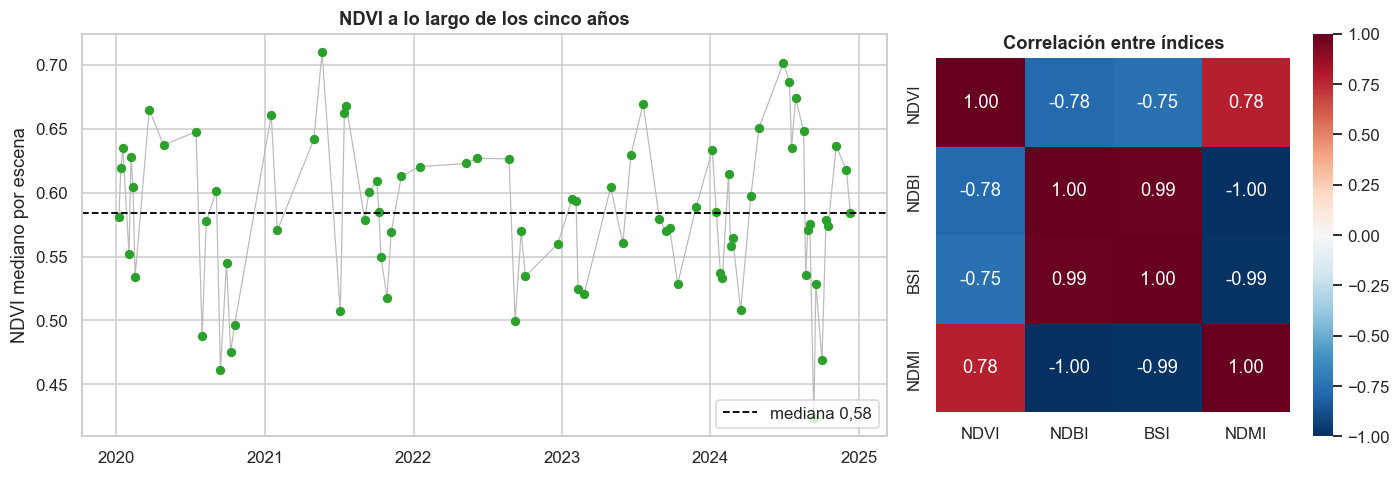

In [14]:
print(f"NDVI mediano sobre las escenas medio limpias: {fmt(optico.NDVI.median(), 2)}")
print("Mediana de cada índice:")
for k in ("NDVI", "NDBI", "NDMI", "BSI"):
    print(f"  {k}: {fmt(optico[k].median(), 3)}")
print(f"Correlación entre NDMI y NDBI: {fmt(optico.NDMI.corr(optico.NDBI), 3)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1.1]})

ax1.plot(optico.fecha, optico.NDVI, "-", color="#bbbbbb", lw=0.8, zorder=1)
ax1.scatter(optico.fecha, optico.NDVI, color="#2ca02c", s=26, zorder=2)
ax1.axhline(optico.NDVI.median(), color="black", ls="--", lw=1.2,
            label=f"mediana {fmt(optico.NDVI.median(), 2)}")
ax1.set_ylabel("NDVI mediano por escena"); ax1.set_title("NDVI a lo largo de los cinco años")
ax1.legend(loc="lower right")

corr = optico[["NDVI", "NDBI", "BSI", "NDMI"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax2, square=True)
ax2.set_title("Correlación entre índices")
plt.tight_layout()
plt.show()

El NDVI mediano se sostiene alto, cerca de 0,58, lo que confirma que el recuadro de Cali tiene bastante verde mezclado con la mancha urbana. Por otro lado, NDMI y NDBI tienen correlación de -1 exacta. No es casualidad: con las bandas disponibles los dos índices se calculan con el mismo par B08 y B11, así que uno es el negativo del otro y cargan la misma información. Para el modelado solo aporta uno de los dos, el otro es espejo. El BSI, en cambio, sí agrega algo distinto porque mete también el rojo y el azul.

## 8. Que todo caiga en su sitio

Para cruzar Sentinel-2 con los gases de Sentinel-5P y con las estaciones, las imágenes tienen que estar bien plantadas en el mapa y compartir el mismo sistema. Revisamos sobre una muestra de escenas de los cuatro tiles que el sistema de coordenadas, el tamaño de celda y las dimensiones de la grilla sean uniformes.

In [15]:
muestra = inv.groupby("tile").head(3)
info = []
for r in muestra.itertuples():
    with rasterio.open(jp2(r.path, "B02")) as s10:
        crs, res10, shp = s10.crs, s10.res[0], s10.shape
    with rasterio.open(jp2(r.path, "SCL")) as s20:
        res20 = s20.res[0]
    info.append({"crs": str(crs), "res_10m": res10, "res_20m": res20, "ancho_px": shp[1]})
dfg = pd.DataFrame(info)

print("Sistemas de coordenadas distintos:", ", ".join(dfg.crs.unique()))
print("Tamaños de celda de las bandas de 10 m:", ", ".join(fmt(x, 0) for x in sorted(dfg.res_10m.unique())), "m")
print("Tamaños de celda de las bandas de 20 m:", ", ".join(fmt(x, 0) for x in sorted(dfg.res_20m.unique())), "m")
print("Ancho de la grilla en píxeles:", ", ".join(fmt(x) for x in sorted(dfg.ancho_px.unique())))

Sistemas de coordenadas distintos: EPSG:32618
Tamaños de celda de las bandas de 10 m: 10 m
Tamaños de celda de las bandas de 20 m: 20 m
Ancho de la grilla en píxeles: 10.980


Todas las escenas comparten el mismo sistema, EPSG:32618 (UTM zona 18 norte), con celdas exactas de 10 y 20 metros y una grilla de 10.980 píxeles de lado. La precisión de ubicación que reporta el proveedor es mejor a 12 metros, suficiente para alinear con la grilla gruesa de Sentinel-5P, que mide en kilómetros. A 10 metros, en cambio, ese margen sí pesa cuando se recorta el pedacito de imagen alrededor de cada estación, y conviene tenerlo presente al emparejar.

## 9. Lo que verá el modelo de imagen

Hasta aquí miramos números y distribuciones, pero el modelo no recibe tablas, recibe imágenes. Falta ver la ciudad como la arma el satélite, juntando el rojo, el verde y el azul en una sola foto. Como las bandas crudas se ven muy oscuras, estiramos cada una entre sus percentiles 2 y 98 solo para que el ojo distinga; los números que entran al modelo siguen siendo la reflectancia corregida, no este estirón.

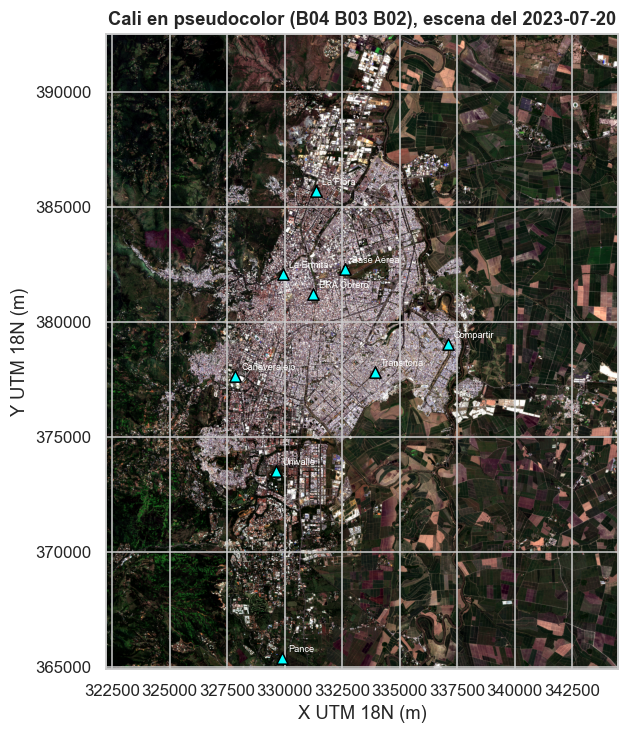

In [16]:
rgb = np.dstack([estirar(reflectancia(leer(mejor.path, b))) for b in ("B04", "B03", "B02")])

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(rgb, extent=[XMIN, XMAX, YMIN, YMAX], origin="upper")
for nom, (lon, lat) in ESTACIONES.items():
    x, y = _tr.transform(lon, lat)
    ax.scatter(x, y, marker="^", c="cyan", s=55, edgecolors="black", zorder=5)
    ax.annotate(nom, (x, y), fontsize=6, color="white", xytext=(4, 4), textcoords="offset points")
ax.set_title(f"Cali en pseudocolor (B04 B03 B02), escena del {mejor.fecha.date()}")
ax.set_xlabel("X UTM 18N (m)"); ax.set_ylabel("Y UTM 18N (m)")
plt.show()

Se reconoce la ciudad: la mancha gris del casco urbano en el centro, el verde de los cerros al occidente y el cuadriculado de los cultivos hacia el oriente. Pero el modelo no traga la ciudad entera de una. Trabaja con recortes de 224 por 224 píxeles, el tamaño que espera el encoder de imagen. Para hacerlo concreto, recortamos uno centrado en la estación de Univalle. A 10 metros por píxel, ese cuadro cubre poco más de dos kilómetros de lado.

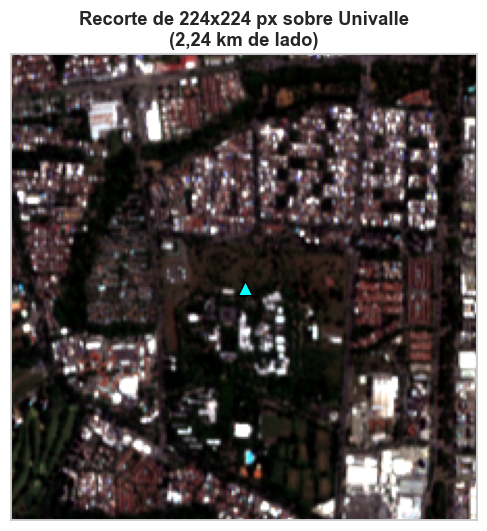

In [17]:
PIX_M, CHIP = 10, 224
est = "Univalle"
ex, ey = _tr.transform(*ESTACIONES[est])
medio = CHIP * PIX_M / 2
canales = []
for b in ("B04", "B03", "B02"):
    with rasterio.open(jp2(mejor.path, b)) as src:
        win = from_bounds(ex - medio, ey - medio, ex + medio, ey + medio, src.transform)
        cruda = src.read(1, window=win, out_shape=(CHIP, CHIP), boundless=True,
                         fill_value=0, resampling=Resampling.bilinear).astype("float64")
    canales.append(estirar(reflectancia(cruda)))
chip = np.dstack(canales)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(chip, origin="upper")
ax.scatter(CHIP / 2, CHIP / 2, marker="^", c="cyan", s=90, edgecolors="black", zorder=5)
ax.set_title(f"Recorte de {fmt(CHIP)}x{fmt(CHIP)} px sobre {est}\n({fmt(CHIP * PIX_M / 1000, 2)} km de lado)")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.show()

Ese cuadro de poco más de dos kilómetros es lo que el encoder vería de una zona como esta. Alcanza para distinguir el barrio, las vías y las manchas de verde, pero recorta el resto de la ciudad. Por eso el recorte y el punto de interés tienen que caer bien encajados: si la imagen está corrida unos metros, el modelo termina mirando una cuadra que no es. Y todo se apoya en lo anterior, porque el pedacito sale del tile que cubre Cali, de una fecha despejada y con la reflectancia ya corregida.

## Lo que nos llevamos

Sentinel-2 entrega la mirada fina que el resto del proyecto necesita, pero con condiciones. De los cuatro tiles descargados solo T18NUJ cae sobre Cali, así que el análisis urbano vive en ese tile y las nueve estaciones de DAGMA quedan dentro de él. La nubosidad tropical se lleva la mitad del material: de 157 escenas, cerca de 79 tienen al menos medio recuadro limpio, y el resto se descarta. El número crudo no sirve hasta restarle el corrimiento de 1.000 y dividir entre 10.000; saltarse ese paso infla la reflectancia y desvía los índices. Sobre lo que queda, la ciudad se ve verde (NDVI cerca de 0,58) y dos de los cuatro índices, NDMI y NDBI, terminan siendo el mismo por las bandas disponibles. Todo esto define el terreno para las fases siguientes: el downscaling y el recorte que alimenta al encoder de imagen se apoyan en un solo tile, en las fechas despejadas y sobre reflectancia corregida.